<a href="https://colab.research.google.com/github/xtina999/rfm-customer-segmentation/blob/main/notebook/RFM_Customer_Segmentation_Analysis_%7C_Online_Retail_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Connecting Google Drive
from google.colab import drive
drive.mount("/content/drive")
%cd /content/drive/MyDrive/ColabNotebooks/code
# import CSV file
import pandas as pd
df = pd.read_csv("online_retail.csv")
df.head()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/ColabNotebooks/code


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
df.shape

(1067371, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [ ]:
# Конвертуємо дату
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Прибираємо рядки без Customer ID
# (без клієнта RFM не порахувати)
df = df.dropna(subset=['Customer ID'])
print(f'Рядків після видалення: {df.shape[0]}')

# Customer ID як integer
df['Customer ID'] = df['Customer ID'].astype(int)

# Прибираємо негативну кількість (повернення товарів)
print(f'Негативних Quantity: {(df["Quantity"] < 0).sum()}')
df = df[df['Quantity'] > 0]

# Прибираємо нульову ціну
print(f'Нульових Price: {(df["Price"] == 0).sum()}')
df = df[df['Price'] > 0]

# Прибираємо дублі
print(f'Дублів: {df.duplicated().sum()}')
df = df.drop_duplicates()

# Додаємо колонку Revenue
df['Revenue'] = df['Quantity'] * df['Price']

print(f'\nФінальний розмір: {df.shape}')
print(df.info())


Рядків після видалення: 824364
Негативних Quantity: 18744
Нульових Price: 71
Дублів: 26124

Фінальний розмір: (779425, 9)
<class 'pandas.core.frame.DataFrame'>
Index: 779425 entries, 0 to 1067370
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  object        
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  int64         
 7   Country      779425 non-null  object        
 8   Revenue      779425 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 59.5+ MB
None


In [ ]:
print(f"Країн: {df['Country'].nunique()}")
print(f"Клієнтів: {df['Customer ID'].nunique()}")
print(f"Період: {df['InvoiceDate'].min()} — {df['InvoiceDate'].max()}")
print(f"Загальний Revenue: ${df['Revenue'].sum():,.0f}")

Країн: 41
Клієнтів: 5878
Період: 2009-12-01 07:45:00 — 2011-12-09 12:50:00
Загальний Revenue: $17,374,804


✅ 779,425 транзакцій

✅ 5,878 унікальних клієнтів

✅ 41 країна

✅ Період: 2 роки (2009-2011)

✅ Загальний дохід: $17,374,804


In [ ]:
import datetime as dt

# Дата відліку — день після останньої покупки
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

Snapshot date: 2011-12-10 12:50:00


In [ ]:
import datetime as dt

# Дата відліку — день після останньої покупки
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)
print(f'Snapshot date: {snapshot_date}')

# Рахуємо RFM по кожному клієнту
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency
    'Invoice':     'nunique',                                  # Frequency
    'Revenue':     'sum'                                       # Monetary
}).reset_index()

# Перейменовуємо
rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Округлюємо Monetary
rfm['Monetary'] = rfm['Monetary'].round(2)

print(rfm.head(10))
print(f'\nСередні значення:')
print(rfm[['Recency','Frequency','Monetary']].mean().round(2))

Snapshot date: 2011-12-10 12:50:00
   Customer ID  Recency  Frequency  Monetary
0        12346      326         12  77556.46
1        12347        2          8   4921.53
2        12348       75          5   2019.40
3        12349       19          4   4428.69
4        12350      310          1    334.40
5        12351      375          1    300.93
6        12352       36         10   2849.84
7        12353      204          2    406.76
8        12354      232          1   1079.40
9        12355      214          2    947.61

Середні значення:
Recency       201.33
Frequency       6.29
Monetary     2955.90
dtype: float64


In [ ]:
# Розбиваємо на 5 груп
# Recency — менше днів = краще (тому reverse)
rfm['R_score'] = pd.qcut(rfm['Recency'], 5,
                          labels=[5,4,3,2,1])

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5,
                          labels=[1,2,3,4,5])

rfm['M_score'] = pd.qcut(rfm['Monetary'], 5,
                          labels=[1,2,3,4,5])

# Загальний RFM score
rfm['RFM_score'] = (rfm['R_score'].astype(str) +
                    rfm['F_score'].astype(str) +
                    rfm['M_score'].astype(str))

print(rfm.head())

   Customer ID  Recency  Frequency  Monetary R_score F_score M_score RFM_score
0        12346      326         12  77556.46       2       5       5       255
1        12347        2          8   4921.53       5       4       5       545
2        12348       75          5   2019.40       3       4       4       344
3        12349       19          4   4428.69       5       3       5       535
4        12350      310          1    334.40       2       1       2       212


In [ ]:
def segment_customer(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    m = int(row['M_score'])

    if r >= 4 and f >= 4:
        return 'Champions'
    elif f >= 3 and r >= 2:
        return 'Loyal Customers'
    elif r >= 3 and f <= 3 and m <= 3:
        return 'Potential Loyalists'
    elif r >= 4 and f <= 1:
        return 'New Customers'
    elif r == 3 and f <= 1:
        return 'Promising'
    elif r <= 3 and f >= 3 and m >= 3:
        return 'At Risk'
    elif r <= 1 and f >= 4 and m >= 4:
        return 'Cant Lose Them'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Hibernating'
    else:
        return 'Lost'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

# Перевіряємо розподіл
print(rfm['Segment'].value_counts())
print(f'\nВсього клієнтів: {len(rfm)}')

Segment
Loyal Customers        1772
Champions              1482
Hibernating            1280
Potential Loyalists     772
Lost                    364
At Risk                 197
Promising                 9
New Customers             2
Name: count, dtype: int64

Всього клієнтів: 5878


In [ ]:
# Зберігаємо фінальний файл
rfm.to_csv('rfm_segments.csv', index=False)

# Також зберігаємо з деталями транзакцій
df_with_segment = df.merge(
    rfm[['Customer ID', 'Segment',
         'Recency', 'Frequency', 'Monetary',
         'R_score', 'F_score', 'M_score']],
    on='Customer ID'
)
df_with_segment.to_csv('retail_with_rfm.csv', index=False)

print('Файли збережені!')
print(rfm.head())

Файли збережені!
   Customer ID  Recency  Frequency  Monetary R_score F_score M_score  \
0        12346      326         12  77556.46       2       5       5   
1        12347        2          8   4921.53       5       4       5   
2        12348       75          5   2019.40       3       4       4   
3        12349       19          4   4428.69       5       3       5   
4        12350      310          1    334.40       2       1       2   

  RFM_score          Segment  
0       255  Loyal Customers  
1       545        Champions  
2       344  Loyal Customers  
3       535  Loyal Customers  
4       212      Hibernating  


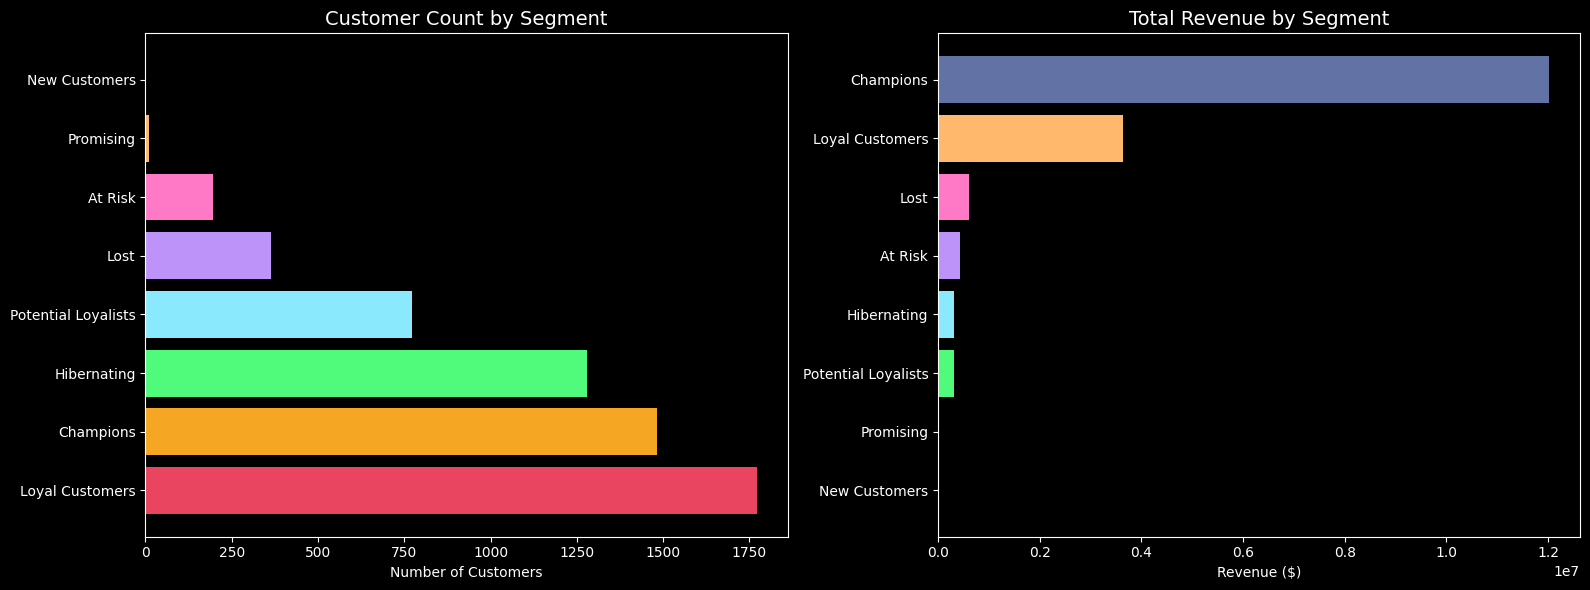

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Налаштування стилю
plt.style.use('dark_background')
colors = ['#e94560','#f5a623','#50fa7b',
          '#8be9fd','#bd93f9','#ff79c6',
          '#ffb86c','#6272a4']

# 1. Кількість клієнтів по сегментах
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

segment_counts = rfm['Segment'].value_counts()

axes[0].barh(segment_counts.index,
             segment_counts.values,
             color=colors)
axes[0].set_title('Customer Count by Segment',
                   fontsize=14, color='white')
axes[0].set_xlabel('Number of Customers')

# 2. Revenue по сегментах
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values()

axes[1].barh(segment_revenue.index,
             segment_revenue.values,
             color=colors)
axes[1].set_title('Total Revenue by Segment',
                   fontsize=14, color='white')
axes[1].set_xlabel('Revenue ($)')

plt.tight_layout()
plt.show()